# Customer Churn Analysis

## Project Overview

This project analyses customer churn behaviour for a telecommunications company using SQL, Python, machine learning, and Tableau.

The objective is to identify key churn drivers, segment high-risk customers, and provide actionable retention recommendations.

In [1]:
print("Customer Churn Analysis Started")

Customer Churn Analysis Started


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/Telco_Customer_Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

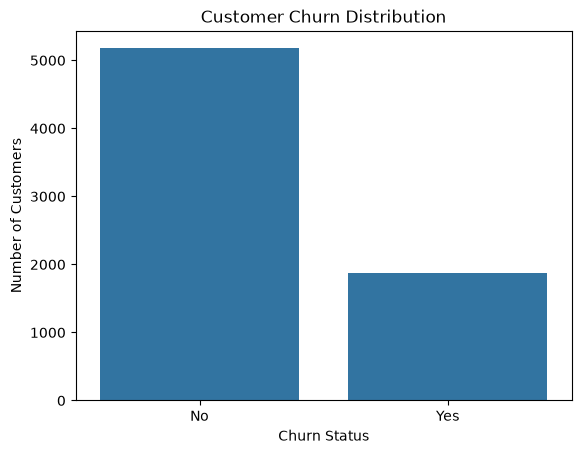

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=df,
    x='Churn'
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

## Initial Finding

The dataset contains 7,043 customers, with approximately 26.6% of customers having churned. 
Although the majority of customers remain active, churn represents a significant retention challenge.

In [9]:
df_clean = df.copy()

In [10]:
df_clean['TotalCharges'] = pd.to_numeric(
    df_clean['TotalCharges'],
    errors='coerce'
)

In [11]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df_clean = df_clean.dropna()

In [14]:
df_clean.shape

(7032, 21)

In [15]:
df_clean['Churn_Flag'] = df_clean['Churn'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

In [16]:
df_clean['Customer_Lifetime_Value'] = (
    df_clean['MonthlyCharges'] * df_clean['tenure']
)

In [17]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Customer_Lifetime_Value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,141.40


## Churn Rate by Contract Type

In [18]:
contract_churn = (
    df_clean.groupby('Contract')['Churn_Flag']
    .mean()
    .reset_index()
)

contract_churn['Churn_Rate'] = contract_churn['Churn_Flag'] * 100

contract_churn

,Contract,Churn_Flag,Churn_Rate
0,Month-to-month,0.427097,42.709677
1,One year,0.112772,11.277174
2,Two year,0.028487,2.848665


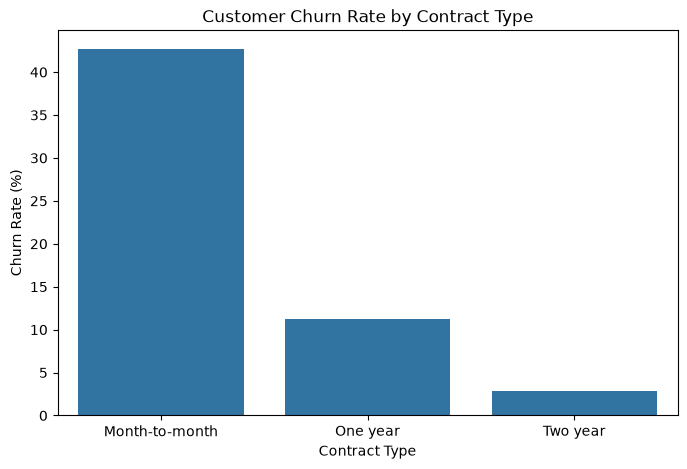

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_churn,
    x='Contract',
    y='Churn_Rate'
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

## Churn Rate by Tenure

In [20]:
df_clean['Tenure_Group'] = pd.cut(
    df_clean['tenure'],
    bins=[0,12,24,48,100],
    labels=[
        '0-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49+ Months'
    ]
)

In [21]:
tenure_churn = (
    df_clean.groupby('Tenure_Group', observed=False)['Churn_Flag']
    .mean()
    .reset_index()
)

tenure_churn['Churn_Rate'] = tenure_churn['Churn_Flag'] * 100

tenure_churn

,Tenure_Group,Churn_Flag,Churn_Rate
0,0-12 Months,0.476782,47.678161
1,13-24 Months,0.287109,28.710938
2,25-48 Months,0.203890,20.388959
3,49+ Months,0.095132,9.513176


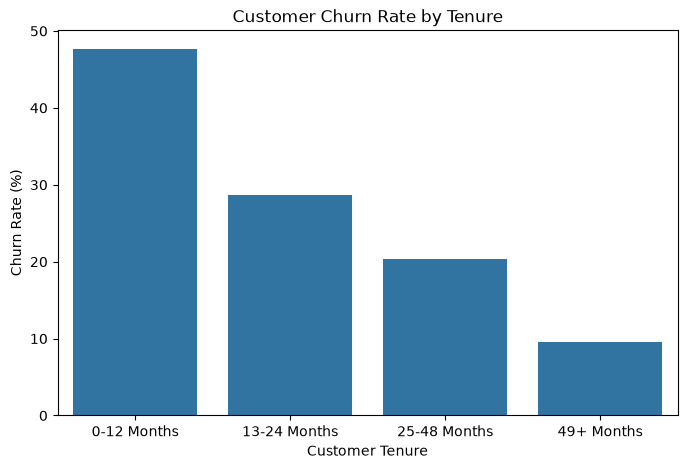

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tenure_churn,
    x='Tenure_Group',
    y='Churn_Rate'
)

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

## Customer Lifetime Value & Churn

In [23]:
clv_churn = (
    df_clean.groupby('Churn')['Customer_Lifetime_Value']
    .mean()
    .reset_index()
)

clv_churn

,Churn,Customer_Lifetime_Value
0,No,2555.203283
1,Yes,1531.608828


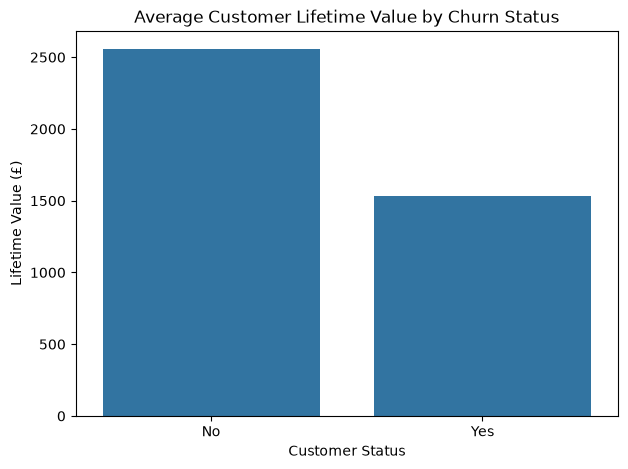

In [24]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=clv_churn,
    x='Churn',
    y='Customer_Lifetime_Value'
)

plt.title("Average Customer Lifetime Value by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Lifetime Value (£)")

plt.show()

## Monthly Charges vs Churn

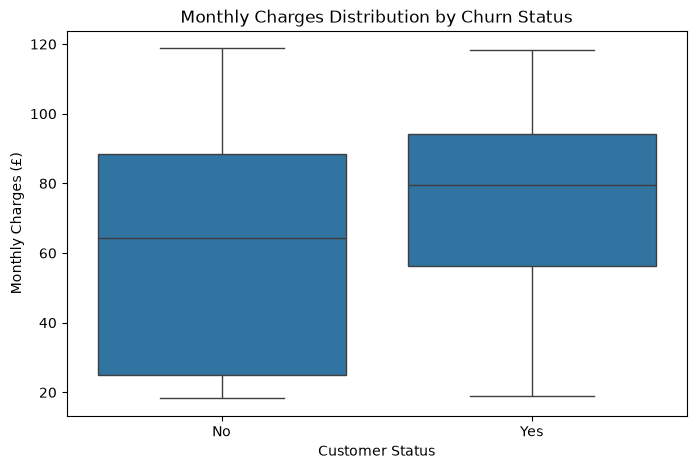

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges (£)")

plt.show()

## Payment Method Analysis

In [26]:
payment_churn = (
    df_clean.groupby('PaymentMethod')['Churn_Flag']
    .mean()
    .reset_index()
)

payment_churn['Churn_Rate'] = payment_churn['Churn_Flag'] * 100

payment_churn.sort_values(
    'Churn_Rate',
    ascending=False
)

,PaymentMethod,Churn_Flag,Churn_Rate
2,Electronic check,0.452854,45.285412
3,Mailed check,0.192020,19.201995
0,Bank transfer (automatic),0.167315,16.731518
1,Credit card (automatic),0.152531,15.253123


In [27]:
id="f1b7w2"
df_clean['Risk_Segment'] = np.where(
    (df_clean['Contract'] == 'Month-to-month') &
    (df_clean['tenure'] <= 12) &
    (df_clean['MonthlyCharges'] > df_clean['MonthlyCharges'].mean()),
    'High Risk',
    np.where(
        (df_clean['Contract'] == 'Month-to-month') &
        (df_clean['tenure'] <= 24),
        'Medium Risk',
        'Low Risk'
    )
)

In [28]:
id="c4q8xk"
risk_analysis = (
    df_clean.groupby('Risk_Segment')['Churn_Flag']
    .agg(
        Customers='count',
        Churn_Rate='mean'
    )
    .reset_index()
)

risk_analysis['Churn_Rate'] = (
    risk_analysis['Churn_Rate'] * 100
)

risk_analysis

,Risk_Segment,Customers,Churn_Rate
0,High Risk,979,67.517875
1,Low Risk,4301,13.182981
2,Medium Risk,1752,36.586758


In [29]:
df_clean.dtypes

customerID                      str
gender                          str
SeniorCitizen                 int64
Partner                         str
Dependents                      str
tenure                        int64
PhoneService                    str
MultipleLines                   str
InternetService                 str
OnlineSecurity                  str
OnlineBackup                    str
DeviceProtection                str
TechSupport                     str
StreamingTV                     str
StreamingMovies                 str
Contract                        str
PaperlessBilling                str
PaymentMethod                   str
MonthlyCharges              float64
TotalCharges                float64
Churn                           str
Churn_Flag                    int64
Customer_Lifetime_Value     float64
Tenure_Group               category
Risk_Segment                    str
dtype: object

## Creating the modelling dataset

In [30]:
model_df = df_clean.drop(
    columns=[
        'customerID',
        'Churn',
        'Risk_Segment',
        'Tenure_Group'
    ]
)

In [31]:
model_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Flag,Customer_Lifetime_Value
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,1936.30
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,107.70
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1903.50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,141.40


## Separate features and target

In [32]:
X = model_df.drop('Churn_Flag', axis=1)

y = model_df['Churn_Flag']

In [33]:
X.shape, y.shape

((7032, 20), (7032,))

## Encode categorical variables

In [34]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [35]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Customer_Lifetime_Value,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,29.85,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,1936.30,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,107.70,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,1903.50,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,141.40,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Train/Test Split

In [36]:
import sys

print(sys.executable)

c:\Users\benmc\Documents\Projects\Customer Churn Analysis\Python\venv\Scripts\python.exe


In [37]:
import sklearn
import pandas
import numpy

print("Environment ready")

Environment ready


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
X_train.shape, X_test.shape

((5625, 31), (1407, 31))

## Train the Logistic Regression Model

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

c:\Users\benmc\Documents\Projects\Customer Churn Analysis\Python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Make Predictions

In [41]:
y_pred = model.predict(X_test)

## Check Accuracy

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.8031272210376688

## Confusion Matrix

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[916, 117],
       [160, 214]])

## Full Classification Report

In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Extract the churn drivers

In [45]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,0.677067
29,PaymentMethod_Electronic check,0.384224
27,PaperlessBilling_Yes,0.293550
10,MultipleLines_Yes,0.278292
9,MultipleLines_No phone service,0.255554
0,SeniorCitizen,0.194037
22,StreamingTV_Yes,0.193867
24,StreamingMovies_Yes,0.164205
30,PaymentMethod_Mailed check,0.073272
28,PaymentMethod_Credit card (automatic),0.037575


In [46]:
feature_importance.tail(10)

,Feature,Coefficient
19,TechSupport_No internet service,-0.103999
17,DeviceProtection_No internet service,-0.103999
21,StreamingTV_No internet service,-0.103999
16,OnlineBackup_Yes,-0.213425
7,Dependents_Yes,-0.230525
20,TechSupport_Yes,-0.420905
8,PhoneService_Yes,-0.456277
14,OnlineSecurity_Yes,-0.458270
25,Contract_One year,-0.743187
26,Contract_Two year,-1.348678


In [47]:
import sys

print(sys.executable)

c:\Users\benmc\Documents\Projects\Customer Churn Analysis\Python\venv\Scripts\python.exe


## Export Dataset for Tableau

In [48]:

df_clean.to_csv(
    "../Data/customer_churn_clean.csv",
    index=False
)

In [49]:
feature_importance.to_csv(
    "../Data/churn_feature_importance.csv",
    index=False
)